In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config

In [2]:
# Plot settings
xmap = {"n_clusters": "Number of clusters", "eps": "Epsilon", "min_samples": "Minimum number of samples"}
score_name_map = {"calinski_harabasz": "Calinski-Harabasz Score", "silhouette": "Silhouette Score", "davies_bouldin": "Davies-Bouldin Score", "nnoise": "Noise [%]", "nclusters": "Number of Clusters"}
c_blue = sns.color_palette("tab10")[0]
c_orange = sns.color_palette("tab10")[1]

In [3]:
def plot_score(df, x, legend_loc=None):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8.27, 8.27*0.3))

    # Plot lines
    l1 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="calinski_harabasz", ax=axs[0], c=c_blue, label="MinMax")
    l2 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="davies_bouldin", ax=axs[1], c=c_blue, label="MinMax")
    l3 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="silhouette", ax=axs[2], c=c_blue, label="MinMax")
    
    l4 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="calinski_harabasz", ax=axs[0], c=c_orange, label="MinMax-UMAP")
    l5 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="davies_bouldin", ax=axs[1], c=c_orange, label="MinMax-UMAP")
    l6 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="silhouette", ax=axs[2], c=c_orange, label="MinMax-UMAP")
   
    # Define labels
    l1.set_xlabel(None)
    l1.set_ylabel(None)
    l1.set_title(r"Calinski-Harabasz Score $\uparrow$", fontsize=11)
    l1.tick_params(labelsize=8)
    l1.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l2.set_xlabel(None)
    l2.set_ylabel(None)
    l2.set_title(r"Davies-Bouldin Score $\downarrow$", fontsize=11)
    l2.tick_params(labelsize=8)
    l2.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l3.set_xlabel(None)
    l3.set_ylabel(None)
    l3.set_title(r"Silhouette Score $\uparrow$", fontsize=11)
    l3.tick_params(labelsize=8)
    l3.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    fig.supxlabel(xmap[x], fontsize=11, y=0.04)
    
    plt.tight_layout()

In [4]:
def find_steepest_gradient(df, value_col="calinski_harabasz"):
    """ Find steepest gradient for DBSCAN in an eps-min_samples heatmap using value_col as value column. """
    temp = df.copy()
    
    # Normalize columns for consistent scaling
    temp['eps_norm'] = (temp['eps'] - temp['eps'].min()) / (temp['eps'].max() - temp['eps'].min())
    temp['min_samples_norm'] = (temp['min_samples'] - temp['min_samples'].min()) / (temp['min_samples'].max() - temp['min_samples'].min())
    temp['calinski_norm'] = (temp[value_col] - temp[value_col].min()) / (temp[value_col].max() - temp[value_col].min())
    
    # Pivot to create a 2D grid
    grid = temp.pivot(index='min_samples_norm', columns='eps_norm', values='calinski_norm')
    grid = grid.interpolate(method='linear', axis=0).interpolate(method='linear', axis=1)  # Fill missing values

    # Calculate gradients
    grad_eps, grad_min_samples = np.gradient(grid.values)  # Numerical differentiation

    # Compute gradient magnitude
    grad_magnitude = np.sqrt(grad_eps**2 + grad_min_samples**2)

    # Find the index of the maximum gradient
    max_idx = np.unravel_index(np.argmax(grad_magnitude), grad_magnitude.shape)
    max_min_samples_norm = grid.index[max_idx[0]]
    max_eps_norm = grid.columns[max_idx[1]]

    # Map back to original scale
    max_eps = max_eps_norm * (temp['eps'].max() - temp['eps'].min()) + temp['eps'].min()
    max_min_samples = max_min_samples_norm * (temp['min_samples'].max() - temp['min_samples'].min()) + temp['min_samples'].min()

    return max_eps, max_min_samples

In [5]:
def plot_heatmap(df, x="min_samples", y="eps", color="nclusters", title="Sweep of DBSAN (on original data)", vmax=None, mask=None, annot=True, patch=None):
    """ Plot heatmap using 2 variables and compute steepest gradient. """
    df_temp = df.copy()
    df_temp = df_temp.sort_values([y, x])
    
    idx = df_temp[y].unique()
    cols = df_temp[x].unique()
    field = pd.DataFrame(df_temp[color].to_numpy().reshape(len(idx), len(cols)), index=idx, columns=cols)

    if mask is not None:
        field = field[mask]
            
    h = sns.heatmap(data=field, cbar_kws={'label': score_name_map[color]}, annot=annot, fmt='g', cmap="gray", vmax=vmax)
    h.figure.axes[-1].yaxis.label.set_size(11)
    plt.gca().invert_yaxis()
    if patch:
        h.add_patch(Rectangle((np.where(cols == patch[1])[0][0], np.where(idx == patch[0])[0][0]), 1, 1, fill=False, edgecolor="red", lw=2))
    plt.xlabel(x, fontsize=11)
    plt.ylabel(y, fontsize=11)
    plt.title(title, fontsize=11)
    plt.tick_params(axis='both', which='minor', labelsize=8)
    plt.tight_layout()

    steepest_gradient_eps, steepest_gradient_min_samples = find_steepest_gradient(df, value_col=color)

    return field, (steepest_gradient_eps, steepest_gradient_min_samples)

In [6]:
# def find_max_diff(field):
#     diff_max = 0
#     col_max0 = 0
#     row_max0 = 0
#     col_max1 = 0
#     row_max1 = 0
    
#     def update(diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new, diff_max, col_max0, row_max0, col_max1, row_max1):
#         if diff_new > diff_max:
#             return diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new
#         else:
#             return diff_max, col_max0, row_max0, col_max1, row_max1
    
#     for col_idx, col in enumerate(field.columns):
#         for row_idx, row in enumerate(field.index):
#             n = field.iloc[row_idx, col_idx]
    
#             # Init parameters
#             diff_l = 0
#             diff_r = 0
#             diff_u = 0
#             diff_d = 0
    
#             # Compute differences to all neighbouring table entries
#             # Column left
#             if col_idx != 0:
#                 diff_l = abs(n - field.iloc[row_idx, col_idx-1])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_l, col_idx, row_idx, col_idx-1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Column right
#             if col_idx != len(field.columns) - 1:
#                 diff_r = abs(n - field.iloc[row_idx, col_idx+1])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_r, col_idx, row_idx, col_idx+1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Row up
#             if row_idx != 0:
#                 diff_u = abs(n - field.iloc[row_idx-1, col_idx])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_u, col_idx, row_idx, col_idx, row_idx-1, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Row down
#             if row_idx != len(field.index) - 1:
#                 diff_d = abs(n - field.iloc[row_idx+1, col_idx])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_d, col_idx, row_idx, col_idx, row_idx+1, diff_max, col_max0, row_max0, col_max1, row_max1)

#     return diff_max, col_max0, row_max0, col_max1, row_max1

In [7]:
from pathlib import Path
# Concatenate all result files
dfs = []
for file in Path(config.output_dir_clustering).glob("internal_validation_*_kmeans*.csv"):
    t = pd.read_csv(file)
    dfs.append(t)
    if "Unnamed: 0" in t.columns:
        print(file)
        break

df_kmeans = pd.concat(dfs).reset_index(drop=True)

# Concatenate all result files
dfs = []
for file in Path(config.output_dir_clustering).glob("internal_validation_*_ward*.csv"):
    t = pd.read_csv(file)
    dfs.append(t)
    if "Unnamed: 0" in t.columns:
        print(file)
        break

df_ward = pd.concat(dfs).reset_index(drop=True)

# Concatenate all result files
dfs = []
for file in Path(config.output_dir_clustering).glob("internal_validation_*_dbscan*.csv"):
    t = pd.read_csv(file)
    dfs.append(t)
    if "Unnamed: 0" in t.columns:
        print(file)
        break

df_dbscan = pd.concat(dfs).reset_index(drop=True)

# Load data

In [45]:
df_kmeans = pd.read_csv(f"{config.output_dir_clustering}internal_validation_kmeans.csv")
df_ward = pd.read_csv(f"{config.output_dir_clustering}internal_validation_ward.csv")
df_dbscan = pd.read_csv(f"{config.output_dir_clustering}internal_validation_dbscan.csv")

# Compare across algorithms
Using the finally selected hyperparameter combinations, compare the CVIs for the algorithms. 

In [8]:
def get_query_string(hyp_dict, preproc=None, float_tol=1e-8):
    """ Helper function to assemble a query for a dataframe to filter for hyperparemeters from a given dict. """
    query_parts = []
    for k, v in hyp_dict.items():
        if v is None or (isinstance(v, float) and pd.isna(v)):  
            query_parts.append(f"{k}.isnull()")  # Handle NaN values
        elif isinstance(v, float):  
            query_parts.append(f"({k} >= {v - float_tol} & {k} <= {v + float_tol})")  # Handle float precision
        else:
            query_parts.append(f"{k} == {repr(v)}")  # Handle integers & strings
            
    if preproc:  # Add preprocessing condition only if provided
        query_parts.append(f"preprocessing == {repr(preproc)}")
        
    return " & ".join(query_parts)

In [9]:
# Kmeans original
query_str = get_query_string(hyp_dict=hyp_config.kmeans_original_hyps, preproc="minmax")
ko = df_kmeans.query(query_str)

# Kmeans embedding
query_str = get_query_string(hyp_dict=hyp_config.kmeans_umap_hyps, preproc="minmax_umap")
ke = df_kmeans.query(query_str)

# Ward original
query_str = get_query_string(hyp_dict=hyp_config.ward_original_hyps, preproc="minmax")
wo = df_ward.query(query_str)

# Ward embedding
query_str = get_query_string(hyp_dict=hyp_config.ward_umap_hyps, preproc="minmax_umap")
we = df_ward.query(query_str)

# DBSCAN original
query_str = get_query_string(hyp_dict=hyp_config.dbscan_original_hyps, preproc="minmax", float_tol=1e-8)
do = df_dbscan.query(query_str)

# DBSCAN embedding
query_str = get_query_string(hyp_dict=hyp_config.dbscan_umap_hyps, preproc="minmax_umap", float_tol=1e-8)
de = df_dbscan.query(query_str)

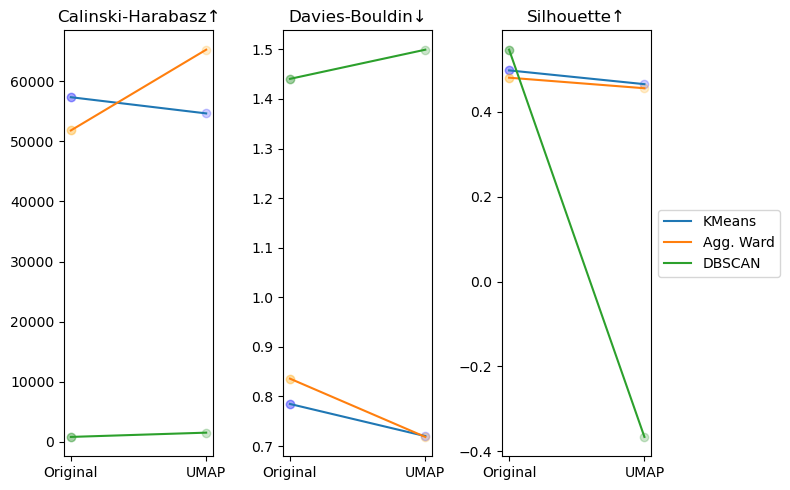

In [10]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 5))
alpha = 0.2
for i, score, score_name in [(0, "calinski_harabasz", "Calinski-Harabasz"), (1, "davies_bouldin", "Davies-Bouldin"), (2, "silhouette", "Silhouette")]:
    title = score_name + "\u2191"
    if score_name == "Davies-Bouldin": 
        title = score_name + "\u2193"
    axs[i].set_title(title)
    axs[i].set_xticks([0, 1], ["Original", "UMAP"])

    axs[i].scatter([0]*len(ko), ko[score], color="blue", alpha=alpha)
    axs[i].scatter([1]*len(ke), ke[score], color="blue", alpha=alpha)
    axs[i].plot([0, 1], [ko[score].mean(), ke[score].mean()], color="tab:blue", label="KMeans")

    axs[i].scatter([0]*len(wo), wo[score], color="orange", alpha=alpha)
    axs[i].scatter([1]*len(we), we[score], color="orange", alpha=alpha)
    axs[i].plot([0, 1], [wo[score].mean(), we[score].mean()], color="tab:orange", label="Agg. Ward")

    axs[i].scatter([0]*len(do), do[score], color="green", alpha=alpha)
    axs[i].scatter([1]*len(de), de[score], color="green", alpha=alpha)
    axs[i].plot([0, 1], [do[score].mean(), de[score].mean()], color="tab:green", label="DBSCAN")
    
axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}score_comparison.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_comparison.png", dpi=1000)
plt.show()

In [11]:
# Correlations between the scores
all = pd.concat([ko, ke, wo, we, do, de])
print(f"Correlation Si-DB: {np.corrcoef(all['silhouette'], all['davies_bouldin'])[0, 1]}")
print(f"Correlation Si-CH: {np.corrcoef(all['silhouette'], all['calinski_harabasz'])[0,1]}")
print(f"Correlation DB-CH: {np.corrcoef(all['calinski_harabasz'], all['davies_bouldin'])[0,1]}")

Correlation Si-DB: -0.4484619797068535
Correlation Si-CH: 0.39684851401228133
Correlation DB-CH: -0.9933920762532932


# KMeans

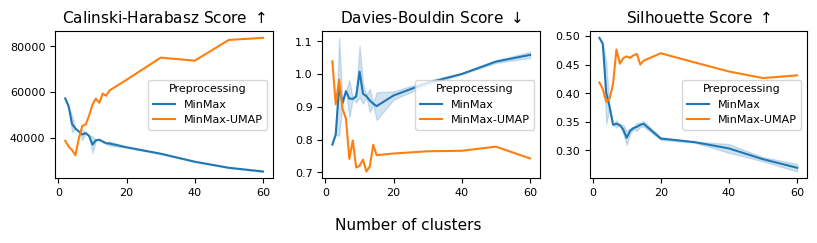

In [12]:
plot_score(df_kmeans, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_kmeans.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_kmeans.png", dpi=1000)
plt.show()

# Agglomerative Ward

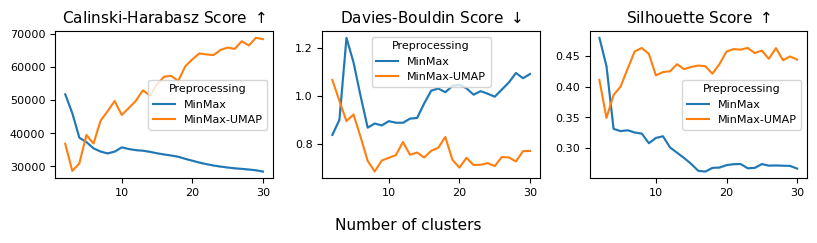

In [13]:
plot_score(df_ward, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_ward.png", dpi=1000)
plt.show()

# DBSCAN

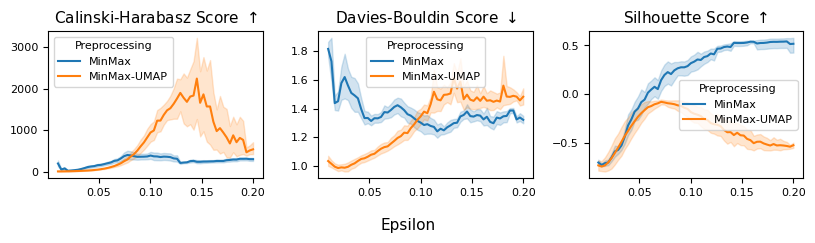

In [14]:
plot_score(df_dbscan, x="eps")
plt.savefig(f"{config.output_dir_plots}score_dbscan_eps.png")
plt.show()

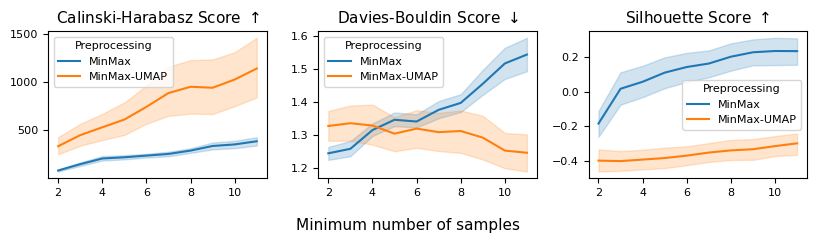

In [15]:
plot_score(df_dbscan, x="min_samples")
plt.savefig(f"{config.output_dir_plots}score_dbscan_min_samples.png")
plt.show()

## Heatmaps
The tuning of 2 parameters instead of one is more complex due to the interaction between the parameters. Therefore, considering plots displaying only one parameter is less descriptive of the actual behaviour. Therefore, we plot the following heatmap.

In [64]:
# Average scores over iterations
df_dbscan_i = df_dbscan.groupby(["eps", "min_samples", "preprocessing", "clustering"]).mean().drop("iteration", axis=1).reset_index()

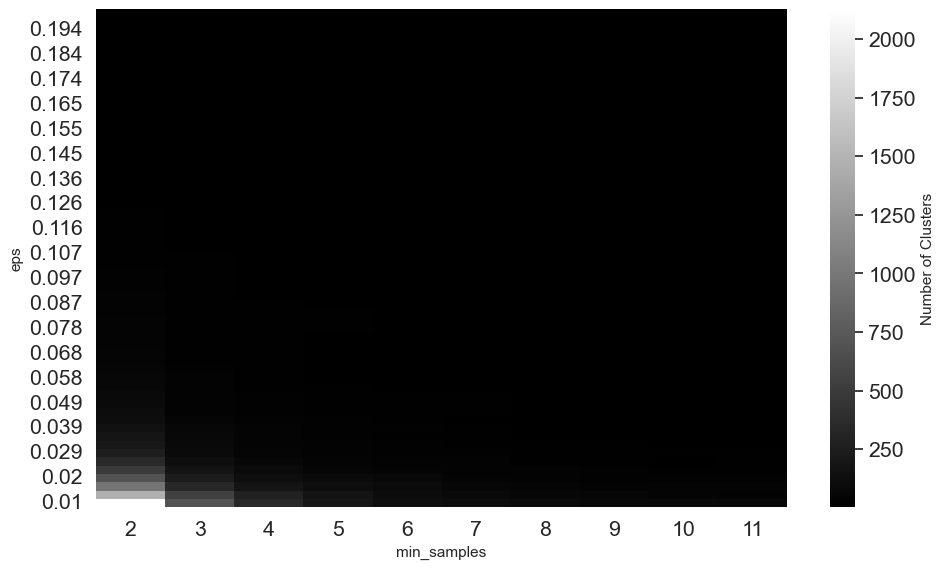

Maximum gradient at (eps, min_samples) = (0.01, 2.0)


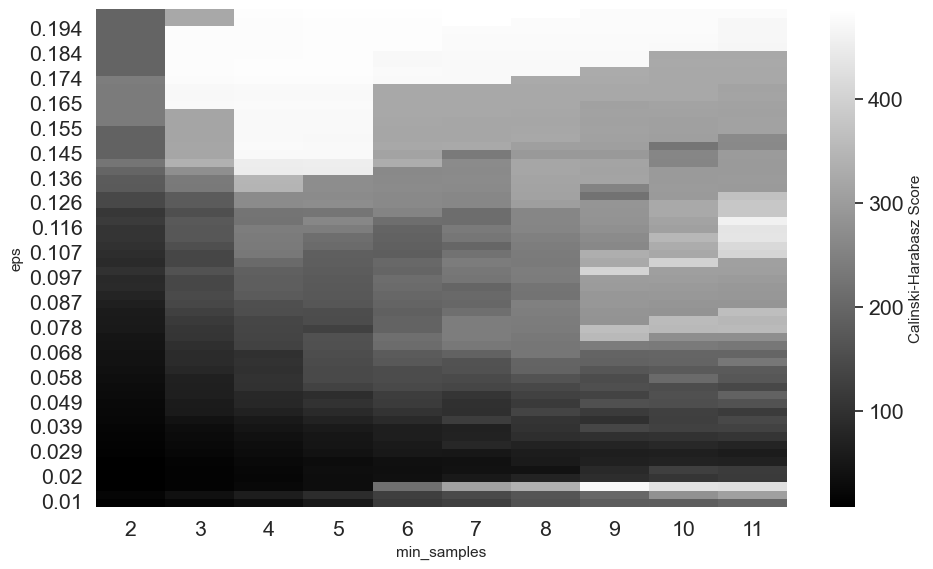

Maximum Calinski-Harabasz score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1190  0.2            7        minmax     dbscan        3.0        25.813384   
1192  0.2            8        minmax     dbscan        3.0        25.769006   

      score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  
1190   23.796416       0.555            1.51              486.0    25.0  
1192   24.312070       0.548            1.54              486.0    26.0  


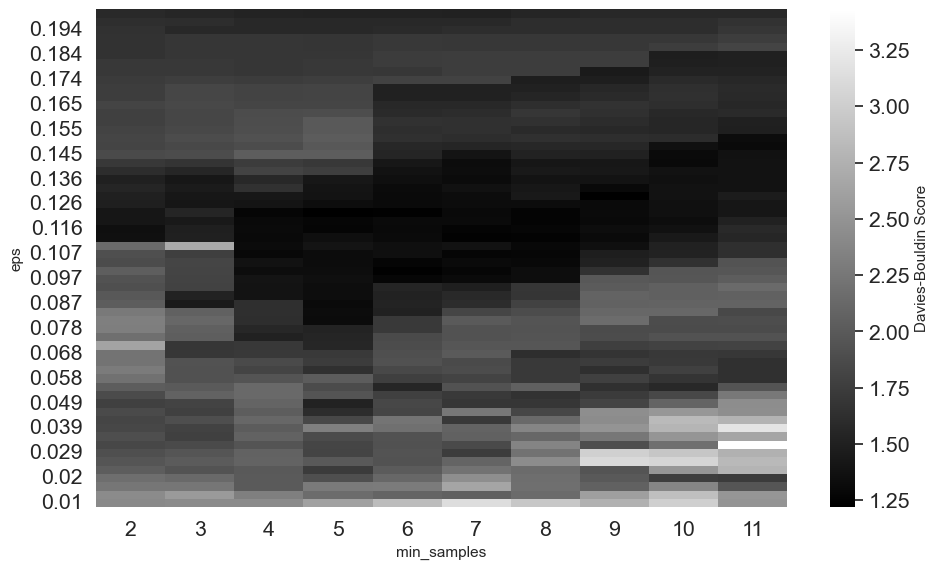

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
706  0.123            5        minmax     dbscan        7.0        16.538108   
754  0.129            9        minmax     dbscan        7.0        17.442106   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  
706   24.138625       0.461            1.22              228.0    63.0  
754   24.432152       0.494            1.22              222.0    94.0  


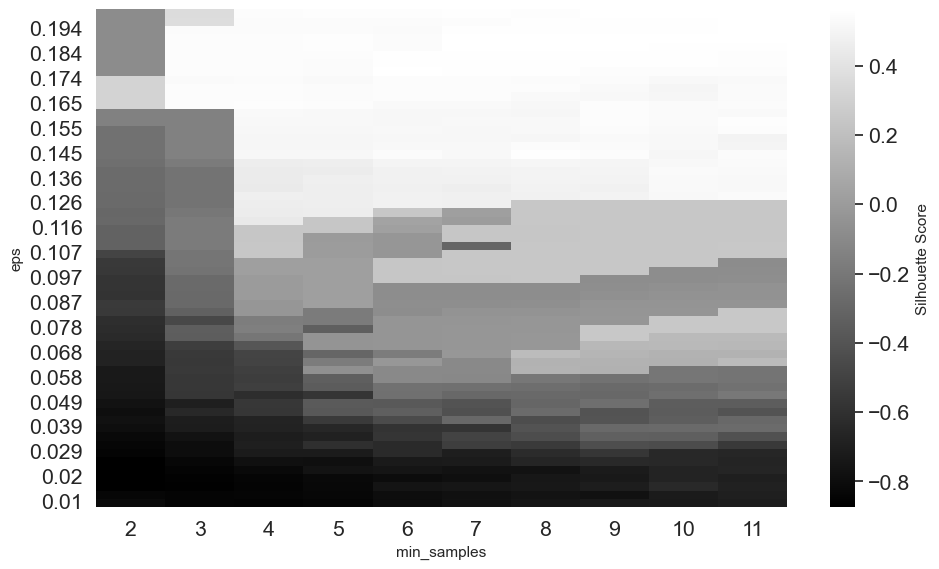

Maximum Silhouette score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1138  0.19           11        minmax     dbscan        3.0        24.951517   

      score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  
1138   24.237628       0.562            1.75              470.0    31.0  


In [65]:
# Plot score heatmap for clustering on original and scores on original
preproc = "minmax"

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(font_scale=1.4)

# prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
#temp.nnoise = round(temp.nnoise*100/49030)
#t = temp[temp.nnoise <= 5]

# Noise fraction
#field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)
#plt.show()
#print(f"Maximum gradient for nnoise at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
#field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
#plt.show()
#print(f"Maximum gradient (nnoise <=5) at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
# print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
# print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
# print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

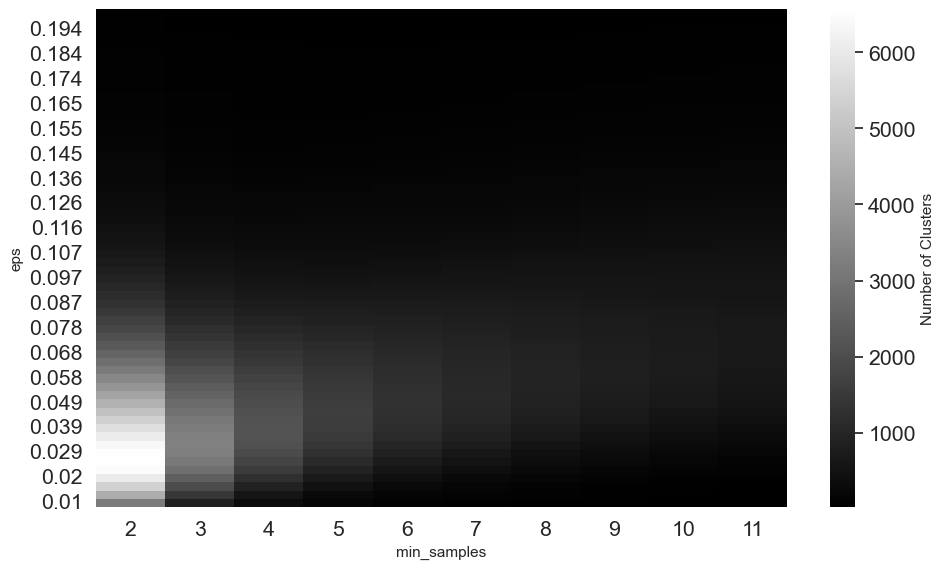

Maximum nclusters gradient at (eps, min_samples) = (0.02, 2.0)


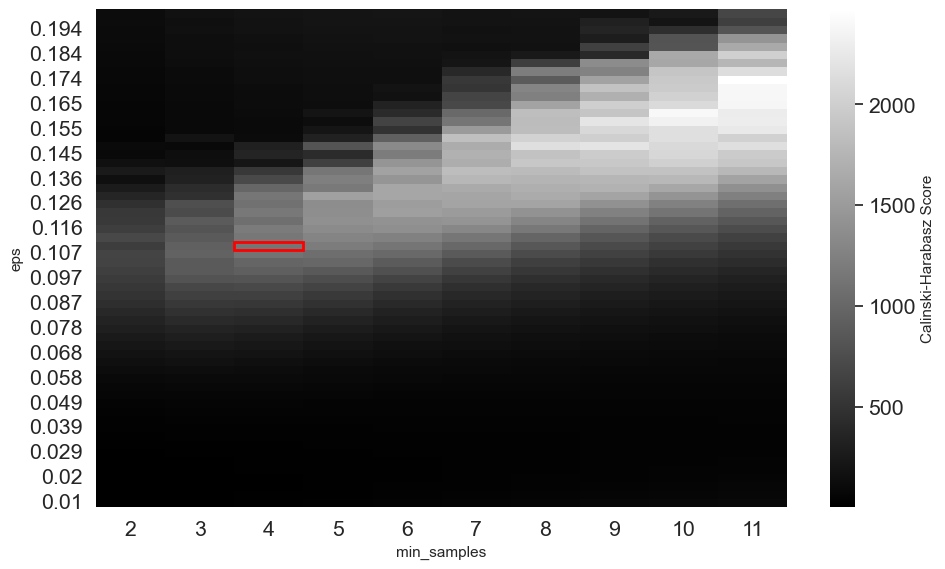

Maximum Calinski-Harabasz score here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1039  0.174           11   minmax_umap     dbscan       80.0        22.559128   

      score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  
1039   23.770741      -0.496            3.52             2471.0  1187.9  


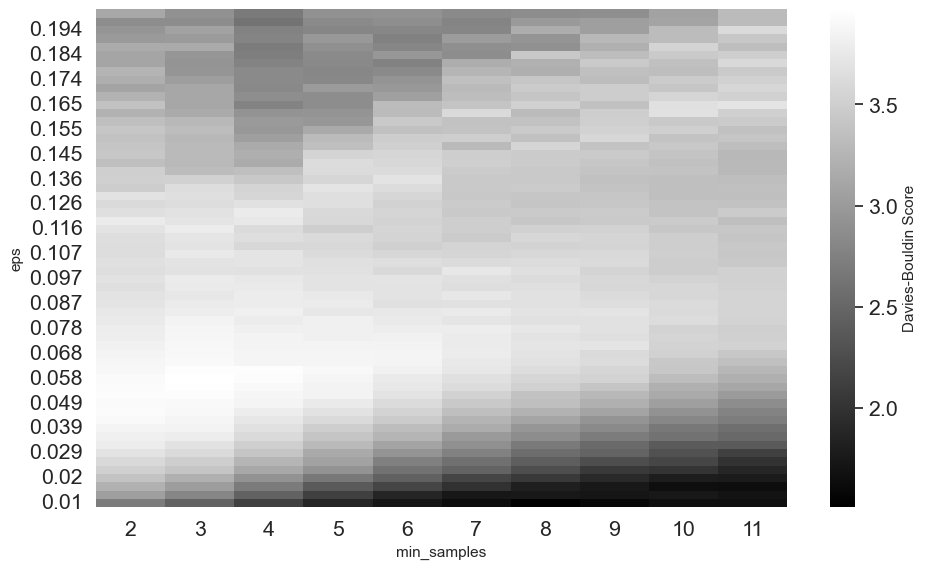

Minimum Davies-Bouldin score here:      eps  min_samples preprocessing clustering  nclusters  clustering_time  \
13  0.01            8   minmax_umap     dbscan       43.0        20.229283   

    score_time  silhouette  davies_bouldin  calinski_harabasz   nnoise  
13   24.918221      -0.766            1.51               59.0  48436.7  


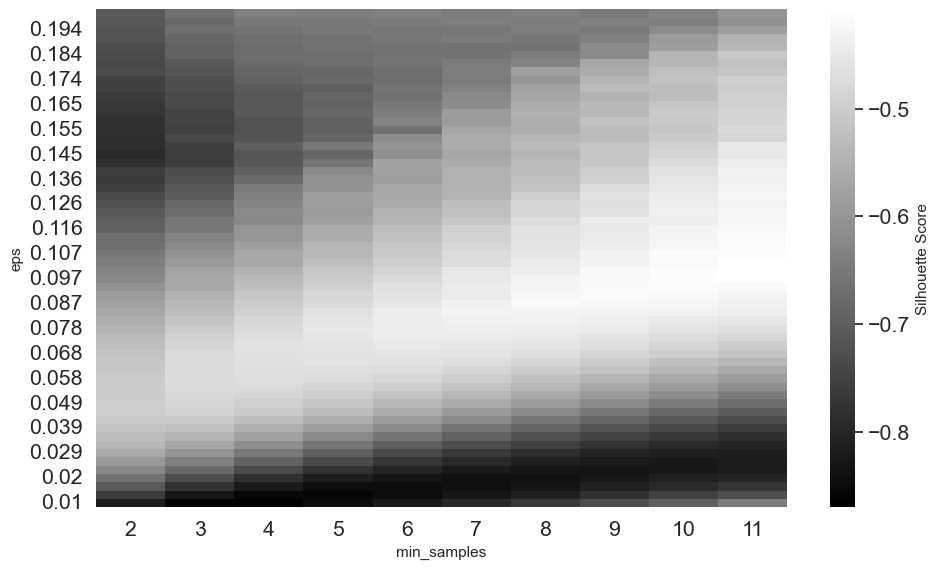

Maximum Silhouette score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
579  0.100           11   minmax_umap     dbscan      516.0        20.494326   
599  0.103           11   minmax_umap     dbscan      487.0        20.128946   

     score_time  silhouette  davies_bouldin  calinski_harabasz   nnoise  
579   22.441873      -0.408            3.52              367.0  10041.3  
599   21.911746      -0.408            3.45              429.0   9170.6  


In [66]:
# Plot score heatmap for clustering on embedding and scores on embedding
preproc = "minmax_umap"

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(font_scale=1.4)

temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
#temp.nnoise = round(temp.nnoise*100/49030)
#t = temp[temp.nnoise <= 5]

# Noise fraction
#field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)  # , vmax=5)
#plt.show()
#print(f"Maximum gradient: {diff_max_n}, between entry(col, row) {col_max0_n, row_max0_n} and entry(col, row) {col_max1_n, row_max1_n}")

# Noise fraction (with mask for 5%)
#field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
#plt.show()
#print(f"Maximum gradient (nnoise <=5): {diff_max_5}, between entry(col, row) {col_max0_5, row_max0_5} and entry(col, row) {col_max1_5, row_max1_5}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum nclusters gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(0.10983051, 3), 4))
# plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
#print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_davies_bouldin.png")
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
#print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_silhouette.png")
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
#print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")


In [67]:
# Steepest gradient for calinski score
preproc = "minmax_umap"
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc]
e, m = find_steepest_gradient(temp)
print(f"Steepest gradiant for DBSCAN on {preproc} was at (eps, min_samples) = {e, m}")

Steepest gradiant for DBSCAN on minmax_umap was at (eps, min_samples) = (0.1838983050847457, 10.0)


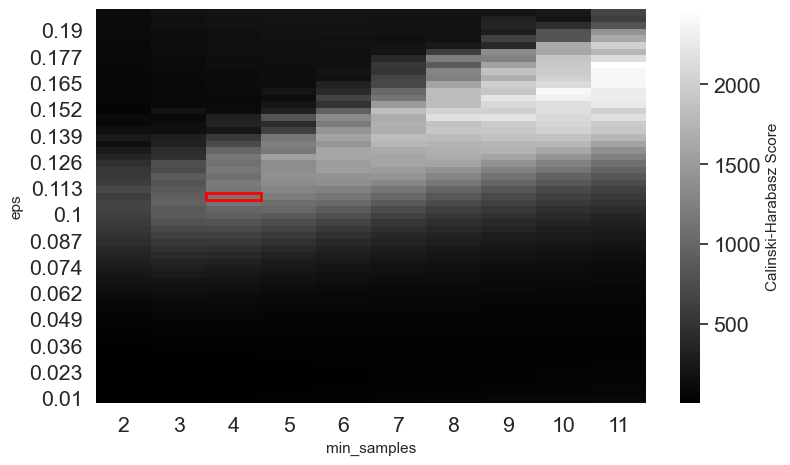

Maximum Calinski-Harabasz score here:         eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1039  0.174           11   minmax_umap     dbscan       80.0        22.559128   

      score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  
1039   23.770741      -0.496            3.52             2471.0  1187.9  


In [68]:
# Plot score heatmap for other preprocessing
preproc = "minmax_umap"

plt.rcParams["figure.figsize"] = (8.27, 8.27*0.6)  # (15, 6)
# sns.set(font_scale=1.4)

# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
#temp.nnoise = round(temp.nnoise*100/49030)
#t = temp[temp.nnoise <= 5]

# Calinski-Harabasz
# field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski", title=f"Sweep of DBSCAN (clustering on {clustering_on}, scores on {scores_on})")
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(0.10983051, 3), 4))
plt.savefig(f"{config.output_dir_plots_high_res}{preproc}_dbscan_sweep_calinski.png", dpi=1000)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
# print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")
